# 02 - Tiền Xử Lý & Feature Engineering

**Mục tiêu:**
- Xử lý missing values
- Xử lý outlier
- Encoding biến phân loại
- Rời rạc hoá cho Apriori
- Lưu dữ liệu đã xử lý

In [1]:
import sys
sys.path.insert(0, '..')
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2.1 Load dữ liệu thô

In [2]:
from src.data.loader import load_raw_data, load_params

params = load_params()
df = load_raw_data()
print(f"Shape ban đầu: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

✅ Loaded data from: D:\Data_Mining\data\raw\heart.csv
   Shape: 920 rows × 16 columns
Shape ban đầu: (920, 16)
Missing values: 1759


## 2.2 Pipeline tiền xử lý

Các bước:
1. Drop cột không cần (`id`, `dataset`)
2. Tạo binary target (num → target)
3. Xử lý missing values (fill median/mode)
4. Encode biến phân loại (Label Encoding)
5. Handle outlier (IQR clipping)

In [3]:
from src.data.cleaner import full_cleaning_pipeline

df_clean = full_cleaning_pipeline(
    df,
    drop_cols=params['preprocessing']['drop_cols'],
    missing_strategy=params['preprocessing']['missing_strategy'],
    missing_threshold=params['preprocessing']['missing_threshold'],
    encode_method=params['preprocessing']['encode_method'],
    handle_outliers=params['preprocessing']['handle_outliers'],
)

🔧 FULL CLEANING PIPELINE

--- Step 1: Dropped columns ['id', 'dataset']

--- Step 2: Create binary target
✅ Created binary target: 0=411, 1=509

--- Step 3: Handle missing values (fill_all)
📊 Missing values before cleaning:
   trestbps: 59 (6.4%)
   chol: 30 (3.3%)
   fbs: 90 (9.8%)
   restecg: 2 (0.2%)
   thalch: 55 (6.0%)
   exang: 55 (6.0%)
   oldpeak: 62 (6.7%)
   slope: 309 (33.6%)
   ca: 611 (66.4%)
   thal: 486 (52.8%)
   📝 trestbps: filled with median = 130.0
   📝 chol: filled with median = 223.0
   📝 fbs: filled with mode = False
   📝 restecg: filled with mode = normal
   📝 thalch: filled with median = 140.0
   📝 exang: filled with mode = False
   📝 oldpeak: filled with median = 0.5
   📝 slope: filled with mode = flat
   📝 ca: filled with median = 0.0
   📝 thal: filled with mode = normal
✅ After cleaning: 0 missing values remain

--- Step 4: Encode categorical (label)
   🔢 sex: {'Female': np.int64(0), 'Male': np.int64(1)}
   🔢 cp: {'asymptomatic': np.int64(0), 'atypical angina

In [4]:
# Kiểm tra kết quả
print(f"Shape sau tiền xử lý: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df_clean['target'].value_counts())
df_clean.head()

Shape sau tiền xử lý: (920, 14)
Missing values: 0

Target distribution:
target
1    509
0    411
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.0,233.0,True,0,150.0,False,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,False,0,108.0,True,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,False,0,129.0,True,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,False,1,187.0,False,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0.0,1,0


## 2.3 Kiểm tra Duplicates

In [5]:
# Kiểm tra duplicate
dupes = df_clean.duplicated().sum()
print(f"Số dòng trùng lặp: {dupes}")
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Đã xoá {dupes} dòng. Shape mới: {df_clean.shape}")
else:
    print("Không có dòng trùng lặp")

Số dòng trùng lặp: 2
Đã xoá 2 dòng. Shape mới: (918, 14)


## 2.4 Thống kê trước vs sau tiền xử lý

In [6]:
# So sánh trước - sau chi tiết
comparison = pd.DataFrame({
    'Before': [df.shape[0], df.shape[1], df.isnull().sum().sum(), df.duplicated().sum()],
    'After': [df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum()]
}, index=['Rows', 'Columns', 'Missing Values', 'Duplicates'])
print("=== THỐNG KÊ TRƯỚC vs SAU TIỀN XỬ LÝ ===")
comparison

=== THỐNG KÊ TRƯỚC vs SAU TIỀN XỬ LÝ ===


,Before,After
Rows,920,918
Columns,16,14
Missing Values,1759,0
Duplicates,0,0


In [7]:
# So sánh mean/std trước-sau cho biến số
before_stats = df.select_dtypes(include='number').describe().loc[['mean','std']].T
after_stats = df_clean.select_dtypes(include='number').describe().loc[['mean','std']].T
compare_stats = pd.DataFrame({
    'Before Mean': before_stats['mean'],
    'After Mean': after_stats['mean'],
    'Before Std': before_stats['std'],
    'After Std': after_stats['std']
}).dropna().round(2)
print("=== SO SÁNH MEAN/STD TRƯỚC-SAU ===")
compare_stats

=== SO SÁNH MEAN/STD TRƯỚC-SAU ===


,Before Mean,After Mean,Before Std,After Std
age,53.51,53.51,9.42,9.43
ca,0.68,0.23,0.94,0.63
chol,199.13,207.07,110.78,91.63
oldpeak,0.88,0.85,1.09,1.02
thalch,137.55,137.70,25.93,25.12
trestbps,132.13,131.73,19.07,16.91


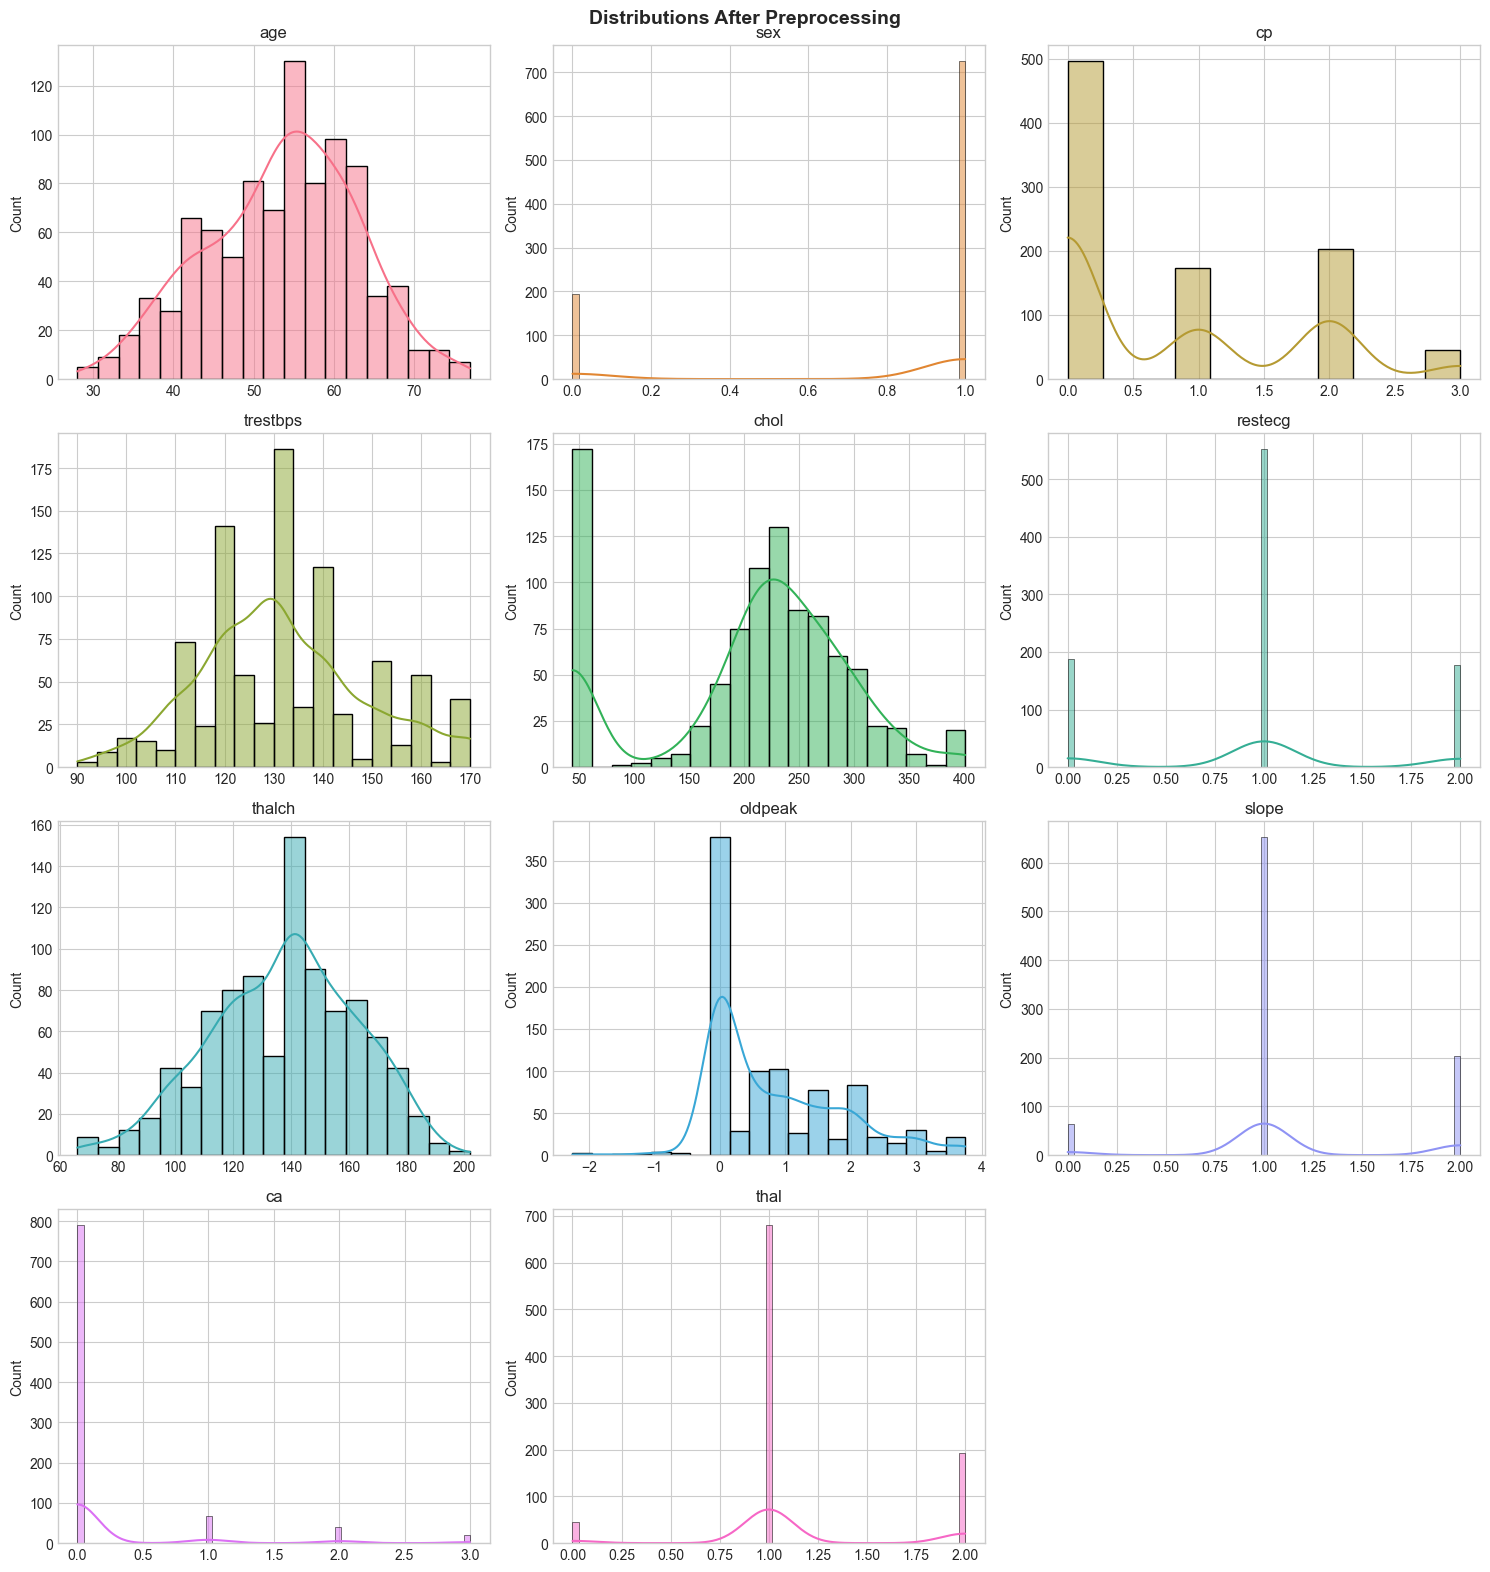

In [8]:
# Phân phối các biến số sau tiền xử lý
from src.visualization.plots import plot_numeric_distributions
fig = plot_numeric_distributions(df_clean, save=False)
plt.suptitle('Distributions After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 Feature Engineering - Rời rạc hoá cho Apriori

In [9]:
from src.features.builder import discretize_for_apriori

# Dùng dữ liệu gốc (chưa encode) cho rời rạc hoá
df_for_disc = df.drop(columns=['id', 'dataset']).copy()
df_for_disc['target'] = (df_for_disc['num'] > 0).astype(int)

df_disc = discretize_for_apriori(df_for_disc)
print(f"\nShape: {df_disc.shape}")
df_disc.head()

✅ Discretized 34 binary features for Apriori

Shape: (920, 34)


,age_young,age_middle,age_senior,age_elderly,is_male,cp_typical_angina,cp_asymptomatic,cp_non-anginal,cp_atypical_angina,bp_normal,...,oldpeak_high,slope_downsloping,slope_flat,slope_upsloping,ca_zero,ca_positive,thal_normal,thal_fixed_defect,thal_reversable,heart_disease
0,0,0,1,0,1,1,0,0,0,0,...,1,1,0,0,1,0,0,1,0,0
1,0,0,0,1,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,1
2,0,0,0,1,1,0,1,0,0,0,...,1,0,1,0,0,1,0,0,1,1
3,1,0,0,0,1,0,0,1,0,0,...,1,1,0,0,1,0,1,0,0,0
4,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,1,0,1,0,0,0


## 2.5 Chuẩn bị X, y cho Modeling

In [10]:
from src.features.builder import select_features_for_modeling

X, y = select_features_for_modeling(df_clean)

✅ X shape: (918, 13), y shape: (918,)
   Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
   Target distribution: {1: np.int64(508), 0: np.int64(410)}


## 2.6 Lưu dữ liệu đã xử lý

In [11]:
import os
os.makedirs(os.path.dirname(params['paths']['processed_data']), exist_ok=True)

# Lưu processed data
df_clean.to_csv(params['paths']['processed_data'], index=False)
print(f"💾 Saved: {params['paths']['processed_data']}")

# Lưu discretized data
df_disc.to_csv(params['paths']['discretized_data'], index=False)
print(f"💾 Saved: {params['paths']['discretized_data']}")

💾 Saved: data/processed/heart_processed.csv
💾 Saved: data/processed/heart_discretized.csv


## 2.7 Nhận xét

- **Missing values:** Xử lý bằng median (số) và mode (phân loại)
- **Encoding:** Label Encoding cho 5 biến phân loại
- **Outlier:** Chỉ clip 4 biến liên tục thật sự (age, trestbps, chol, thalch, oldpeak)
- **Rời rạc hoá:** Tạo được binary features cho Apriori dựa trên ngưỡng y tế
- Dữ liệu sẵn sàng cho bước Mining và Modeling